In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [197]:
df = pd.read_csv('games.csv')

In [198]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [199]:
df['rated'] = df['rated'].astype(int)

In [200]:
df['victory_status'].unique()

array(['outoftime', 'resign', 'mate', 'draw'], dtype=object)

In [201]:
df = pd.get_dummies(df, columns = ['victory_status'], prefix = 'status')
df['status_draw'] = df['status_draw'].astype(int)
df['status_mate'] = df['status_mate'].astype(int)
df['status_outoftime'] = df['status_outoftime'].astype(int)
df['status_resign'] = df['status_resign'].astype(int)
df

,id,rated,created_at,last_move_at,turns,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,status_draw,status_mate,status_outoftime,status_resign
0,TZJHLljE,0,1.504210e+12,1.504210e+12,13,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,0,0,1,0
1,l1NXvwaE,1,1.504130e+12,1.504130e+12,16,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,0,0,0,1
2,mIICvQHh,1,1.504130e+12,1.504130e+12,61,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,0,1,0,0
3,kWKvrqYL,1,1.504110e+12,1.504110e+12,61,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,0,1,0,0
4,9tXo1AUZ,1,1.504030e+12,1.504030e+12,95,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,EfqH7VVH,1,1.499791e+12,1.499791e+12,24,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2,0,0,0,1
20054,WSJDhbPl,1,1.499698e+12,1.499699e+12,82,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2,0,1,0,0
20055,yrAas0Kj,1,1.499698e+12,1.499698e+12,35,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3,0,1,0,0
20056,b0v4tRyF,1,1.499696e+12,1.499697e+12,109,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4,0,0,0,1


In [202]:
df['winner'].unique()
df['winner'] = df['winner'].map({'white' : 0, 'black' : 1, 'draw' : 2})

In [203]:
df = df.drop('id', axis = 1)

In [204]:
df['increment_code'].unique()
new = df['increment_code'].str.split('+', n = 1, expand = True)
df['basetime'] = new[0].astype(int)
df['increment_seconds'] = new[1].astype(int)

In [205]:
df = df.drop('increment_code', axis = 1)

In [206]:
white_count = df['white_id'].value_counts()
black_count = df['black_id'].value_counts()
df['white_experience'] = df['white_id'].map(white_count)
df['black_experience'] = df['black_id'].map(black_count)

In [207]:
df = df.drop(['white_id', 'black_id'], axis = 1)

In [208]:
df['moves'].unique()
df['first_move'] = df['moves'].apply(lambda x: x.split()[0])
df['moves_count'] = df['moves'].apply(lambda x: len(x.split()))
df = df.drop('moves', axis = 1)

In [209]:
df = df.rename(columns = ({'first_move': 'start_move'}))

In [210]:
from sklearn.preprocessing import LabelEncoder

In [211]:
label = LabelEncoder()
df['start_move'] = label.fit_transform(df['start_move'])

In [212]:
df = df.drop('moves_count', axis = 1)

In [213]:
df['opening_eco'].unique()

array(['D10', 'B00', 'C20', 'D02', 'C41', 'B27', 'D00', 'C50', 'B01',
       'A00', 'C02', 'C00', 'C57', 'C55', 'A40', 'B20', 'A25', 'B21',
       'D01', 'C45', 'D06', 'B52', 'D20', 'B06', 'A45', 'B77', 'A21',
       'B70', 'B23', 'B76', 'C21', 'A80', 'A20', 'A04', 'C26', 'C44',
       'E10', 'A41', 'C01', 'A10', 'C18', 'A47', 'C10', 'D80', 'D30',
       'D41', 'A46', 'D31', 'C64', 'C24', 'A43', 'A08', 'B03', 'B29',
       'B02', 'B13', 'B57', 'E20', 'E11', 'C40', 'C11', 'C28', 'B30',
       'A56', 'C65', 'B90', 'B50', 'B51', 'E00', 'C70', 'B11', 'B22',
       'B40', 'B31', 'B18', 'C61', 'C78', 'B10', 'C22', 'C54', 'C68',
       'B12', 'C77', 'A42', 'C42', 'D07', 'B32', 'A22', 'C46', 'B07',
       'A06', 'C60', 'A07', 'A02', 'C58', 'A03', 'B54', 'D03', 'C69',
       'A31', 'D46', 'C34', 'C48', 'C47', 'B24', 'C67', 'E61', 'C53',
       'C23', 'B96', 'A05', 'D92', 'A49', 'C37', 'A09', 'A01', 'C88',
       'B34', 'C03', 'C33', 'A48', 'A11', 'A81', 'B05', 'B53', 'B08',
       'C30', 'A15',

In [214]:
df['opening_category'] = df['opening_eco'].str[0]

In [215]:
df['opening_category'] = label.fit_transform(df['opening_category'])

In [216]:
df = df.drop(['opening_eco', 'opening_name'], axis = 1)

In [217]:
df['rating_diff'] = df['white_rating'] - df['black_rating']

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rated              20058 non-null  int64  
 1   created_at         20058 non-null  float64
 2   last_move_at       20058 non-null  float64
 3   turns              20058 non-null  int64  
 4   winner             20058 non-null  int64  
 5   white_rating       20058 non-null  int64  
 6   black_rating       20058 non-null  int64  
 7   opening_ply        20058 non-null  int64  
 8   status_draw        20058 non-null  int64  
 9   status_mate        20058 non-null  int64  
 10  status_outoftime   20058 non-null  int64  
 11  status_resign      20058 non-null  int64  
 12  basetime           20058 non-null  int64  
 13  increment_seconds  20058 non-null  int64  
 14  white_experience   20058 non-null  int64  
 15  black_experience   20058 non-null  int64  
 16  start_move         200

In [219]:
df.isna().sum()

rated                0
created_at           0
last_move_at         0
turns                0
winner               0
white_rating         0
black_rating         0
opening_ply          0
status_draw          0
status_mate          0
status_outoftime     0
status_resign        0
basetime             0
increment_seconds    0
white_experience     0
black_experience     0
start_move           0
opening_category     0
rating_diff          0
dtype: int64

In [220]:
from sklearn.model_selection import train_test_split

In [241]:
X = df.drop(['winner', 'created_at', 'last_move_at'], axis = 1)
y = df['winner']

In [242]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [243]:
from xgboost import XGBClassifier

In [244]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [245]:
y_pred_xgb = model_xgb.predict(X_test)

In [246]:
print(f"Model's accuracy: {accuracy_score(y_test, y_pred_xgb)}")

Model's accuracy: 0.8905782652043869


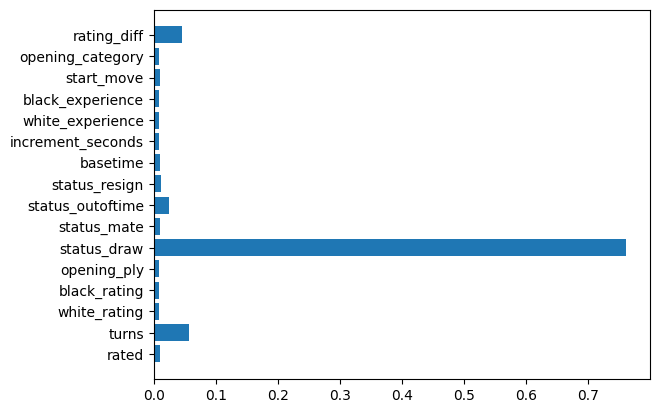

In [247]:
importances = model_xgb.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.show()

In [248]:
from sklearn.model_selection import cross_val_score

In [249]:
scores = cross_val_score(model_xgb, X, y, cv = 5)

In [250]:
print("Accuracy of all predicts:", scores)
print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Accuracy of all predicts: [0.8945663  0.87886341 0.88010967 0.89454001 0.89628522]
Mean Accuracy: 88.89%
Standard Deviation: 0.77%


In [251]:
X_real = df.drop(['winner', 'created_at', 'last_move_at', 'turns', 'status_draw', 'status_mate', 'status_outoftime', 'status_resign'], axis = 1)
y_real = df['winner']

In [252]:
X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

In [253]:
real_model_xgb = XGBClassifier()
real_model_xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [255]:
real_pred = real_model_xgb.predict(X_test)

In [256]:
print(f"Real model's accuracy: {accuracy_score(y_test, real_pred)}")

Real model's accuracy: 0.6308574277168495


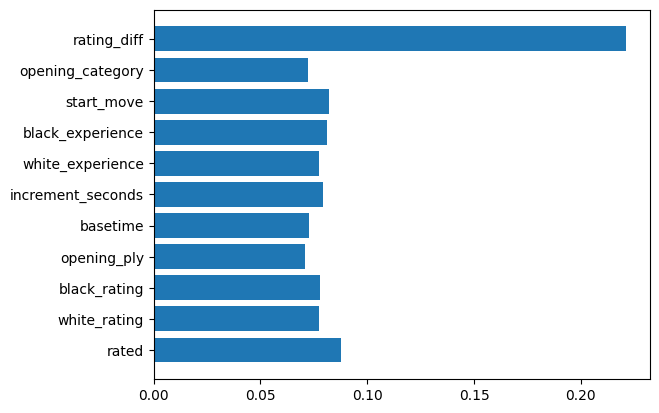

In [258]:
importances = real_model_xgb.feature_importances_
features = X_real.columns
plt.barh(features, importances)
plt.show()

In [260]:
scores = cross_val_score(real_model_xgb, X_real, y_real, cv = 5)
print("Accuracy of all predicts:", scores)
print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Accuracy of all predicts: [0.62711864 0.61440678 0.62412762 0.62802294 0.62203939]
Mean Accuracy: 62.31%
Standard Deviation: 0.49%


In [265]:
import pickle
import os

In [267]:
if not os.path.exists('models'):
    os.makedirs('models')
with open('models/chess_predictor.pkl', 'wb') as file:
    pickle.dump(real_model_xgb, file)
print("Մոդելը հաջողությամբ պահպանվեց 'models/' թղթապանակում:")

Մոդելը հաջողությամբ պահպանվեց 'models/' թղթապանակում:
